# Task 1 — Selective Object Enhancement

**Member 1** | Sharpen a specific colored object while blurring the rest.

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from cv_utils import load_image, show_image, show_images_row, show_before_after, print_analysis
from tasks.task1_selective_enhancement import create_red_mask, create_color_mask, selective_enhance, sharpen_image

print("✅ Imports OK")

✅ Imports OK


## 1. Load Test Image

Place a flower image (with red and/or yellow flowers) in `images/task1/`.


  Analysis: Input Image
  Shape:       (1024, 1536, 3)
  Dtype:       uint8
  Brightness:  74.0 / 255
  Contrast:    51.5 (std dev)
  Range:       [2, 252]



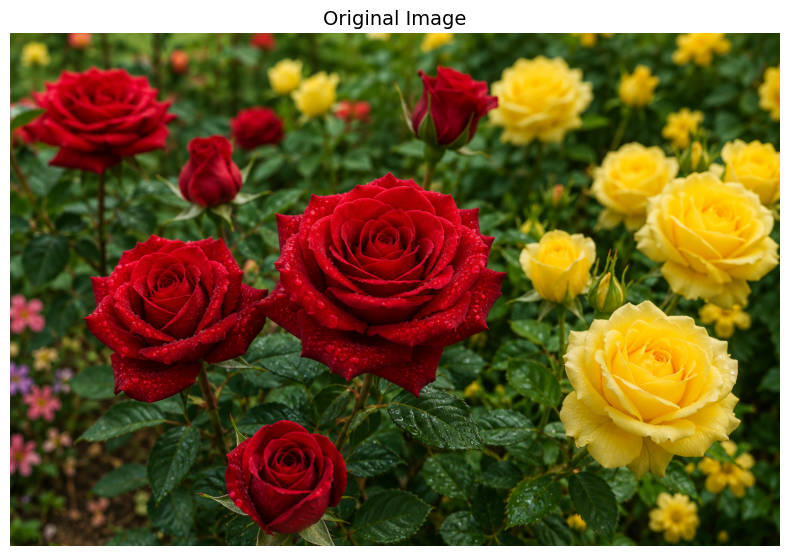

In [12]:
# Load an image — update the filename to match your image
img = load_image('../images/task1/flower.png')  # <-- CHANGE THIS
print_analysis(img, "Input Image")
show_image(img, "Original Image")

## 2. Create Color Masks

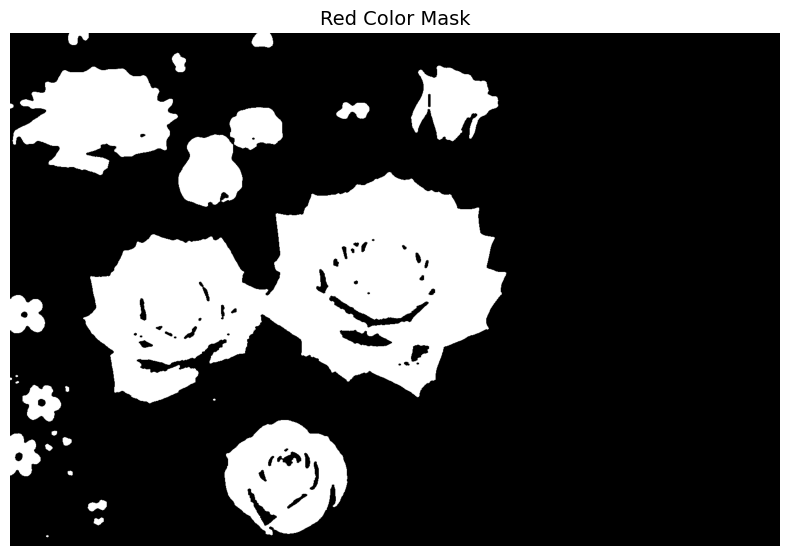

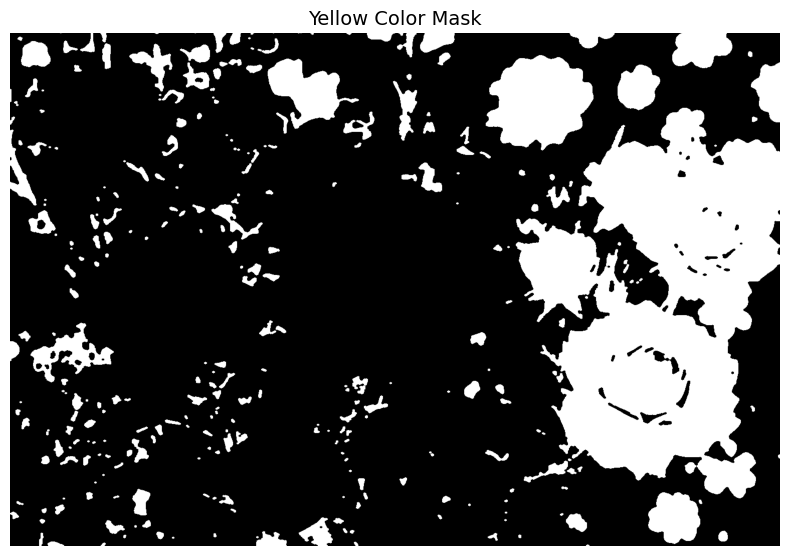

In [13]:
# Red mask (works for red roses, red objects, etc.)
red_mask = create_red_mask(img)
show_image(red_mask, "Red Color Mask", cmap='gray')

# Yellow mask
yellow_mask = create_color_mask(img, lower_hsv=(20, 70, 50), upper_hsv=(35, 255, 255))
show_image(yellow_mask, "Yellow Color Mask", cmap='gray')

# You can adjust HSV ranges for other colors:
# Blue:   (100, 70, 50) to (130, 255, 255)
# Green:  (35, 70, 50) to (85, 255, 255)
# Purple: (130, 70, 50) to (160, 255, 255)

## 3. Apply Selective Enhancement

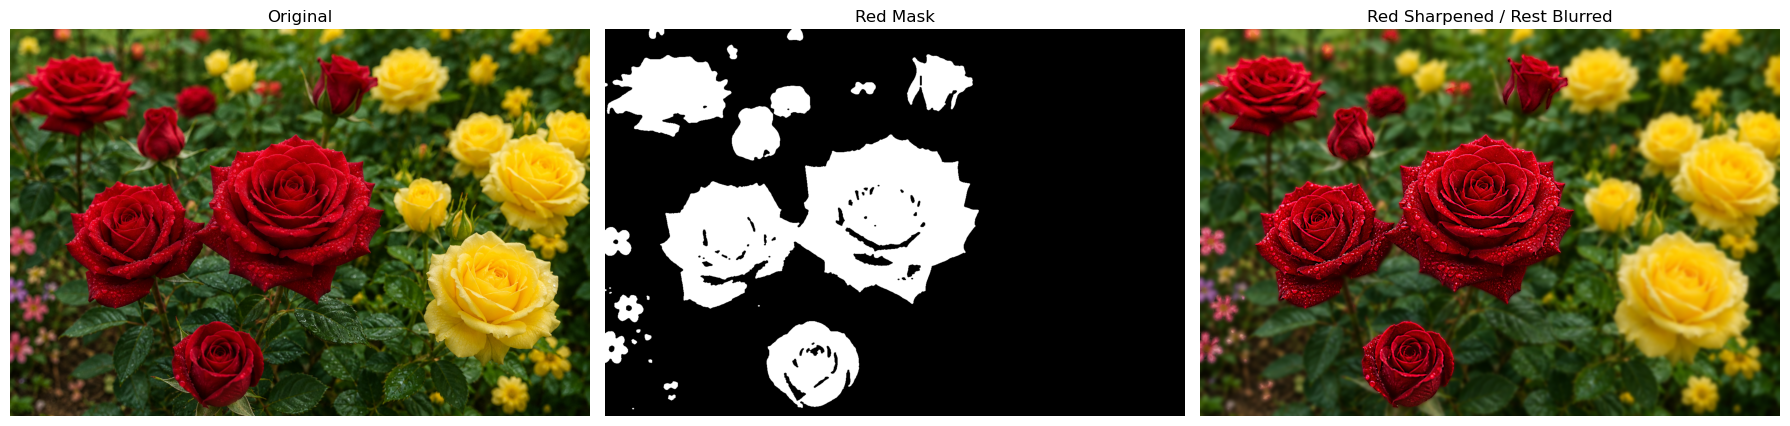

In [14]:
# Sharpen red objects, blur everything else
result_red = selective_enhance(img, red_mask, enhance_sharp=True, blur_ksize=21)

show_images_row(
    [img, red_mask, result_red],
    ["Original", "Red Mask", "Red Sharpened / Rest Blurred"],
    figsize=(18, 6)
)

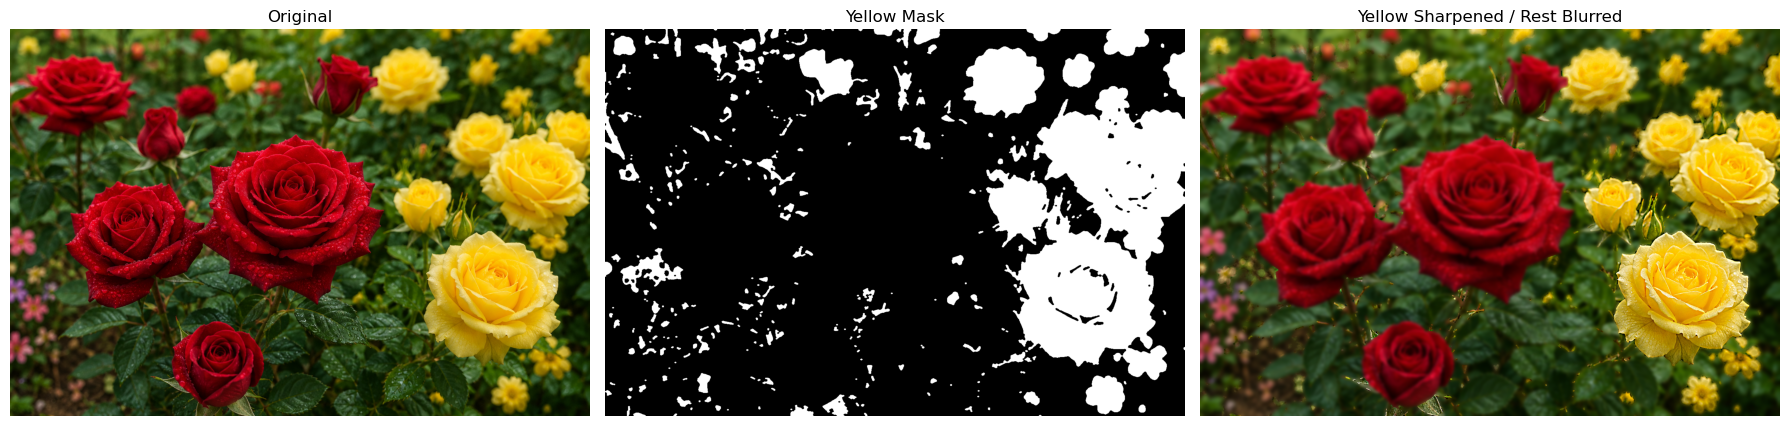

In [15]:
# Sharpen yellow objects instead
result_yellow = selective_enhance(img, yellow_mask, enhance_sharp=True, blur_ksize=21)

show_images_row(
    [img, yellow_mask, result_yellow],
    ["Original", "Yellow Mask", "Yellow Sharpened / Rest Blurred"],
    figsize=(18, 6)
)

## 4. Save Results

In [16]:
os.makedirs('../outputs/task1', exist_ok=True)
cv2.imwrite('../outputs/task1/red_enhanced.png', result_red)
cv2.imwrite('../outputs/task1/yellow_enhanced.png', result_yellow)
cv2.imwrite('../outputs/task1/red_mask.png', red_mask)
print("✅ Saved to outputs/task1/")

✅ Saved to outputs/task1/
